In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm, trange

In [ ]:
%matplotlib inline

In [ ]:
train_n = 100
test_n = 1000
d = 100

In [ ]:
def generate_data():
    X_train = np.random.normal(0,1, size=(train_n,d))
    w_true = np.random.normal(0,1, size=(d,1))
    y_train = X_train.dot(w_true) + np.random.normal(0,0.5,size=(train_n,1))
    X_test = np.random.normal(0,1, size=(test_n,d))
    y_test = X_test.dot(w_true) + np.random.normal(0,0.5,size=(test_n,1))
    return w_true, X_train, y_train, X_test, y_test

# 3.1

In [23]:
def normalized_error(X, y, w):
    numerator = np.linalg.norm(X @ w - y)
    denominator = np.linalg.norm(y)
    return numerator/denominator


f_hat_train, f_hat_test = [], []
for t in range(10):
    w_true, X_train, y_train, X_test, y_test = generate_data()
    w_closed_form = np.linalg.inv(X_train) @ y_train
    f_hat_train.append(normalized_error(X_train, y_train, w_closed_form))
    f_hat_test.append(normalized_error(X_test, y_test, w_closed_form))

print(f"Normalized train error (linalg soln): {np.mean(f_hat_train):.5e}")
print(f"Normalized test error (linalg soln): {np.mean(f_hat_test):.5e}")

Normalized train error (linalg soln): 4.86299e-14
Normalized test error (linalg soln): 1.79594e+00


# 3.2

  0%|          | 0/10 [00:00<?, ?it/s]

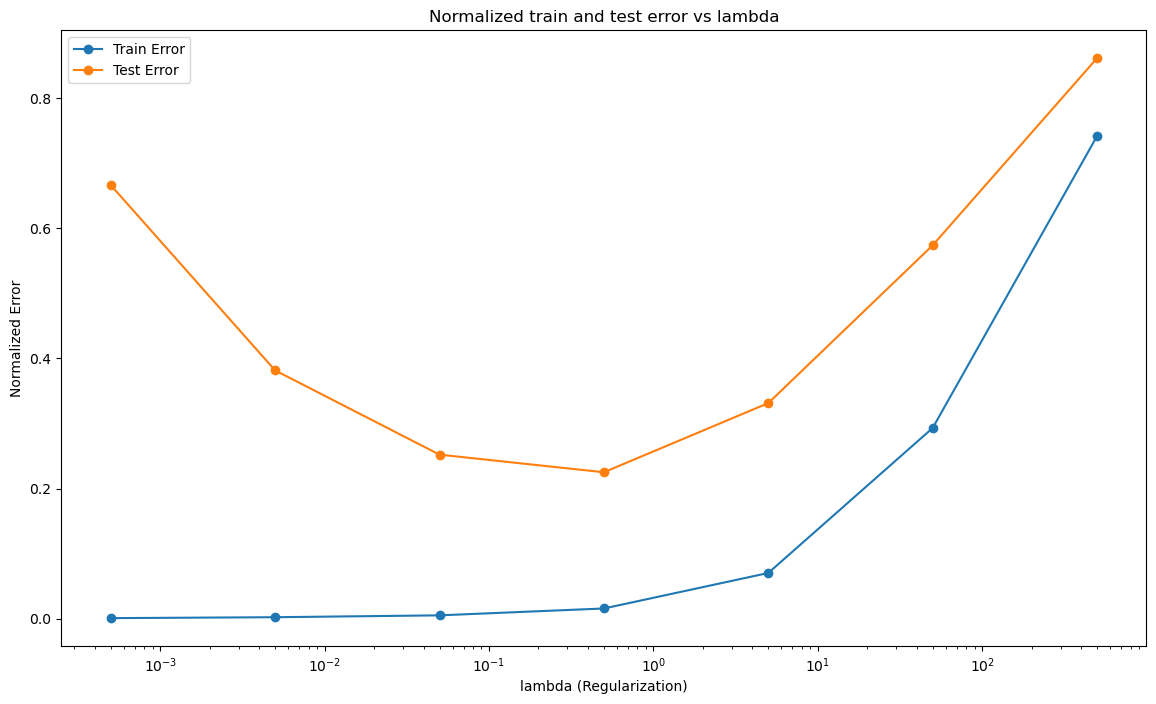

Normalized train error (L2 linalg soln): [np.float64(0.000968886813027252), np.float64(0.002373304489688459), np.float64(0.005227862301171541), np.float64(0.015787904785197582), np.float64(0.0703440155358433), np.float64(0.29313995985795965), np.float64(0.7417119223289175)]
Normalized test error (L2 linalg soln): [np.float64(0.6663376304651203), np.float64(0.38162262770133515), np.float64(0.25214621702597795), np.float64(0.2251107538406195), np.float64(0.3313498411559469), np.float64(0.5738159053403018), np.float64(0.8614152698322298)]


In [39]:
n_trials = 10
l_reg_list = [0.0005, 0.005, 0.05, 0.5, 5, 50, 500]
avg_f_hat_train_per_l, avg_f_hat_test_per_l = [0.0]* len(l_reg_list), [0.0]* len(l_reg_list)
    
for t in trange(n_trials):
    w_true, X_train, y_train, X_test, y_test = generate_data()

    for l_idx, l_reg in enumerate(l_reg_list):
        w_closed_form = np.linalg.solve(X_train.T @ X_train + l_reg * np.eye(d), X_train.T @ y_train) 
        train_loss = normalized_error(X_train, y_train, w_closed_form)
        test_loss = normalized_error(X_test, y_test, w_closed_form)
        avg_f_hat_train_per_l[l_idx] += train_loss
        avg_f_hat_test_per_l[l_idx] += test_loss
        
avg_f_hat_train_per_l = [x / n_trials for x in avg_f_hat_train_per_l]
avg_f_hat_test_per_l = [x / n_trials for x in avg_f_hat_test_per_l]
        

fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='o', label='Train Error')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='o', label='Test Error')
axs.set_xscale('log')
axs.set_xlabel('lambda (Regularization)')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs lambda')
axs.legend()
plt.show()

print(f"Normalized train error (L2 linalg soln): {avg_f_hat_train_per_l}")
print(f"Normalized test error (L2 linalg soln): {avg_f_hat_test_per_l}")

# 3.3

In [ ]:
def sgd(X, y, w, step_size, n_steps):
    w = np.zeros((d, 1))
    for _ in trange(n_steps):
        #pick random data point
        i = np.random.randint(0, train_n)
        xi = X[i:i+1]
        yi = y[i:i+1]
        grad = 2 * (w.T @ xi - yi) * xi
        w -= grad * step_size
    return w

In [ ]:
n_trials = 10
step_size_list = [5e-5, 5e-4, 5e-3]
avg_f_hat_train_per_ss, avg_f_hat_test_per_ss = [0.0]* len(step_size_list), [0.0]* len(step_size_list)
    
for t in trange(n_trials, desc="Trail #"):
    w_true, X_train, y_train, X_test, y_test = generate_data()

    for ss_idx, step_size in enumerate(step_size_list):
        pass  # TODO: implement and update avg_f_hat_train_per_ss, avg_f_hat_test_per_ss

print(f"Normalized train error (SGD): {avg_f_hat_train_per_ss}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_ss}")

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

# 3.4

In [ ]:
def sgd_w_tracking(X, y, X_te, y_te, w, step_size, n_steps, eval_every=100):
    train_errs, test_errs, w_norms = [], [], []
    print(f"Step size: {step_size}")
    for step_ctr in trange(n_steps, desc="SGD iteration"):
        pass  # TODO: implement and update train_errs, test_errs, w_norms
        
    return w, train_errs, test_errs, w_norms

In [ ]:
step_size_list = [5e-5, 5e-3]
f_hat_train_trend_per_ss, f_hat_test_trend_per_ss, w_norm_trend = [None]* len(step_size_list), [None]* len(step_size_list), [None]* len(step_size_list)
f_hat_train_true, f_hat_test_true = [], []
    
w_true, X_train, y_train, X_test, y_test = generate_data()
f_hat_train_true = normalized_error(X_train, y_train, w_true)
f_hat_test_true = normalized_error(X_test, y_test, w_true)

for ss_idx, step_size in enumerate(step_size_list):
    pass  # TODO: compute w_est, train_errors, test_errors, w_est_norms for each step size

    f_hat_train_trend_per_ss[ss_idx] = train_errors
    f_hat_test_trend_per_ss[ss_idx] = test_errors
    w_norm_trend[ss_idx] = w_est_norms

### 3.4 (i)

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000), f_hat_train_trend_per_ss[ss_idx],
             label=f'Train Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], label='Train Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

### 3.4 (ii)

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000001, step=100), f_hat_test_trend_per_ss[ss_idx],
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Test Error')
axs.set_title('Normalized test error vs SGD iteration number')
axs.legend()

### 3.4 (iii)

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000), w_norm_trend[ss_idx],
             label=f'L2 norm of w (SGD, step_size={step_size})')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('L2 norm of w')
axs.set_title('L2 norm of w vs SGD iteration number')
axs.legend()

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000), f_hat_train_trend_per_ss[ss_idx], f'C{ss_idx}',
             label=f'Train Error (SGD, step_size={step_size})')

for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000001, step=100), f_hat_test_trend_per_ss[ss_idx], f'C{ss_idx}--',
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], 'C2', label='Train Error for w*')
axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], 'C2--', label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

# 3.5

In [ ]:
n_trials = 10
r_list = [0, 0.1, 0.5, 1, 10, 20, 30]
avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r = [0.0]* len(r_list), [0.0]* len(r_list), [0.0]* len(r_list)
    
for t in trange(n_trials, desc="Trail #"):
    pass  # TODO: implement and update avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error')

axs.set_xlabel('Radius r of initial weight vector')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs radius of weight vector initialization')
axs.legend()

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

In [ ]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error (SGD)')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Initial Radius')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()